# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [1]:
!pip install xlrd --break-system-packages

In [2]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [3]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)

# 모델링 프로세스 요약

Target : default (0 = 정상, 1 = 채무불이행)

1단계 EDA
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

2단계 데이터 전처리
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

3단계 Train / Test Split
- train_test_split — stratify=y 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

4단계 모델 학습
- Logistic Regression (베이스라인)
- Random Forest
- XGBoost

5단계 모델 평가
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

6단계 피처 중요도
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

7단계 하이퍼파라미터 튜닝 (선택)
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

EDA

In [18]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [19]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [20]:
# 결측치 확인
print("=== 결측치 확인 ===")
print(X_features.isnull().sum())
print(f"\n총 결측치 수 : {X_features.isnull().sum().sum()}")

=== 결측치 확인 ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

총 결측치 수 : 0


In [21]:
# 기술통계 확인
print("=== 기술통계 ===")
X_features.describe()

=== 기술통계 ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# 기술통계 분석 결과

이상값 (전처리 필요)

- EDUCATION : 정의된 값은 1~4 (1=대학원, 2=대학, 3=고등학교, 4=기타) → min=0, max=6 으로 0, 5, 6 은 미정의값 → 4(기타)로 통합 필요
- MARRIAGE : 정의된 값은 1~3 (1=기혼, 2=미혼, 3=기타) → min=0 으로 0 은 미정의값 → 3(기타)으로 통합 필요
- BILL_AMT : 음수값 존재 (과납으로 인한 크레딧 잔액) → 이상치 아님, 그대로 유지

정상 범위 확인

- PAY_0 ~ PAY_6 : -2(소비없음), -1(정상납부), 0(리볼빙), 1~8(연체 개월수) → 음수값은 정상
- AGE : 21 ~ 79세 → 정상 범위
- PAY_AMT : min=0, 최대값 매우 큼 → 극단값 존재하나 실제 납부 데이터로 허용

전처리 필요 항목 요약

- EDUCATION : 0, 5, 6 → 4 로 통합
- MARRIAGE : 0 → 3 으로 통합

C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\2901564093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\2901564093.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\2901564093.py:45: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\2901564093.py:45: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.


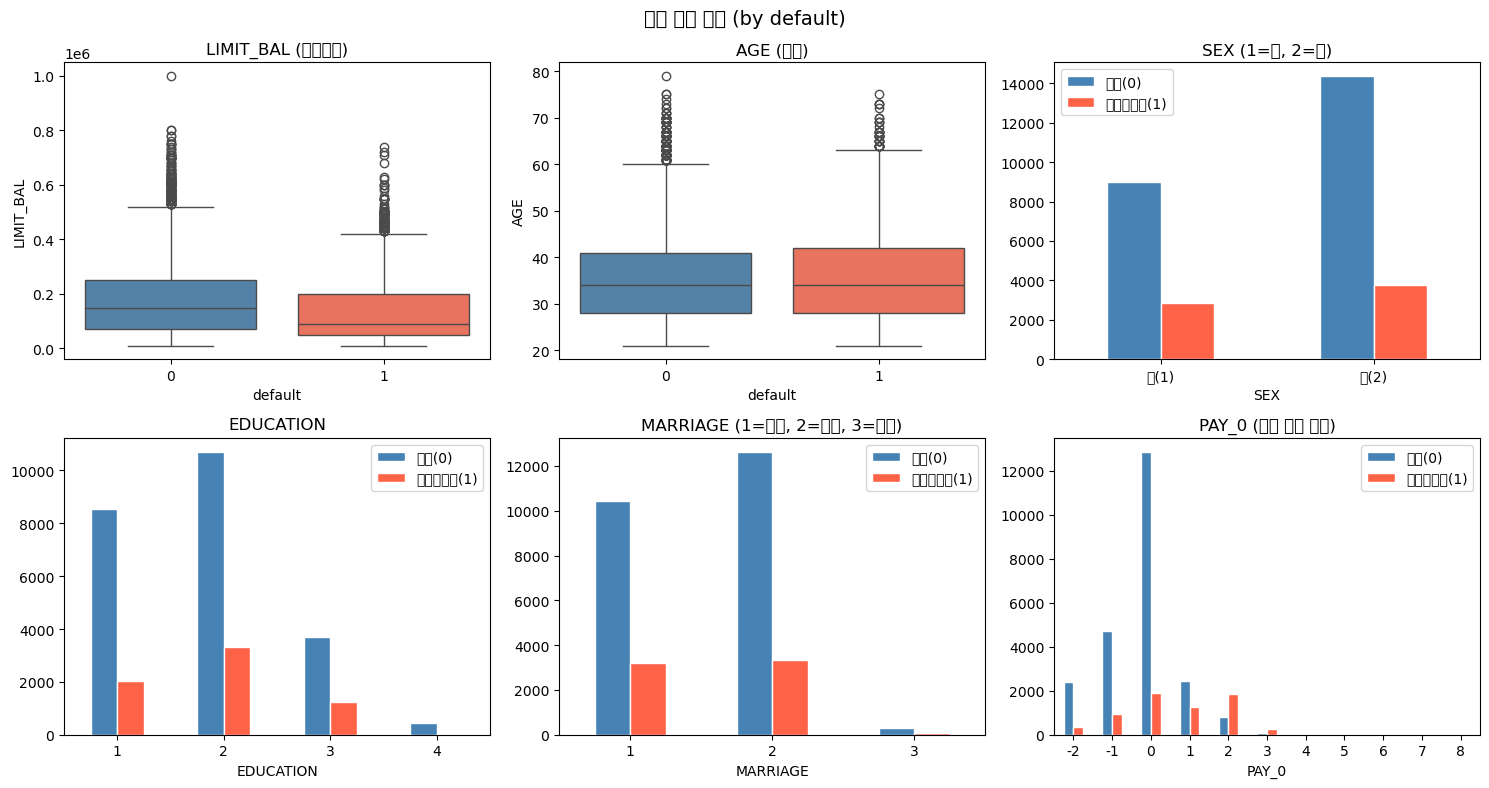

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14)

palette = ['steelblue', 'tomato']

# 1. LIMIT_BAL
sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('LIMIT_BAL (신용한도)')

# 2. AGE
sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('AGE (나이)')

# 3. SEX
sex_ratio = card_df.groupby(['SEX', 'default']).size().unstack()
sex_ratio.plot(kind='bar', ax=axes[0, 2], color=palette, edgecolor='white')
axes[0, 2].set_title('SEX (1=남, 2=여)')
axes[0, 2].set_xticklabels(['남(1)', '여(2)'], rotation=0)
axes[0, 2].legend(['정상(0)', '채무불이행(1)'])

# 4. EDUCATION
edu_ratio = card_df.groupby(['EDUCATION', 'default']).size().unstack()
edu_ratio.plot(kind='bar', ax=axes[1, 0], color=palette, edgecolor='white')
axes[1, 0].set_title('EDUCATION')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(['정상(0)', '채무불이행(1)'])

# 5. MARRIAGE
mar_ratio = card_df.groupby(['MARRIAGE', 'default']).size().unstack()
mar_ratio.plot(kind='bar', ax=axes[1, 1], color=palette, edgecolor='white')
axes[1, 1].set_title('MARRIAGE (1=기혼, 2=미혼, 3=기타)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(['정상(0)', '채무불이행(1)'])

# 6. PAY_0 (최근 연체 상태)
pay_ratio = card_df.groupby(['PAY_0', 'default']).size().unstack()
pay_ratio.plot(kind='bar', ax=axes[1, 2], color=palette, edgecolor='white')
axes[1, 2].set_title('PAY_0 (최근 납부 상태)')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
axes[1, 2].legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()

# 피처 분포 분석 결과**
LIMIT_BAL (신용한도)

- 채무불이행(1) 그룹의 중앙값이 정상(0) 그룹보다 낮음
- 신용한도가 낮을수록 채무불이행 가능성 높음 → 예측에 유효한 피처

AGE (나이)

- 두 그룹 간 분포 차이 거의 없음 → 예측력 낮을 가능성 있음

SEX (성별)

- 여성(2) 이 남성(1) 보다 전체 수가 많음
- 두 그룹 간 채무불이행 비율 큰 차이 없음 → 예측력 낮을 가능성 있음

EDUCATION

- 0, 5, 6 미정의값 데이터 수 매우 적음 → 전처리(4로 통합) 필요 재확인
- 대학(2) 비율이 가장 높음

MARRIAGE

- 0 미정의값 데이터 수 매우 적음 → 전처리(3으로 통합) 필요 재확인
- 기혼(1), 미혼(2) 간 채무불이행 비율 유사

PAY_0 (최근 납부 상태) ★ 핵심 피처

- PAY_0 = 1 이상(연체)일수록 채무불이행(1) 비율이 급격히 증가
- 정상 납부(-1, 0) 구간은 채무불이행 비율 매우 낮음
- PAY_0 이 채무불이행 예측에 가장 영향력 있는 피처로 예상

In [23]:
# 1) 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15424\3119726676.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing fr

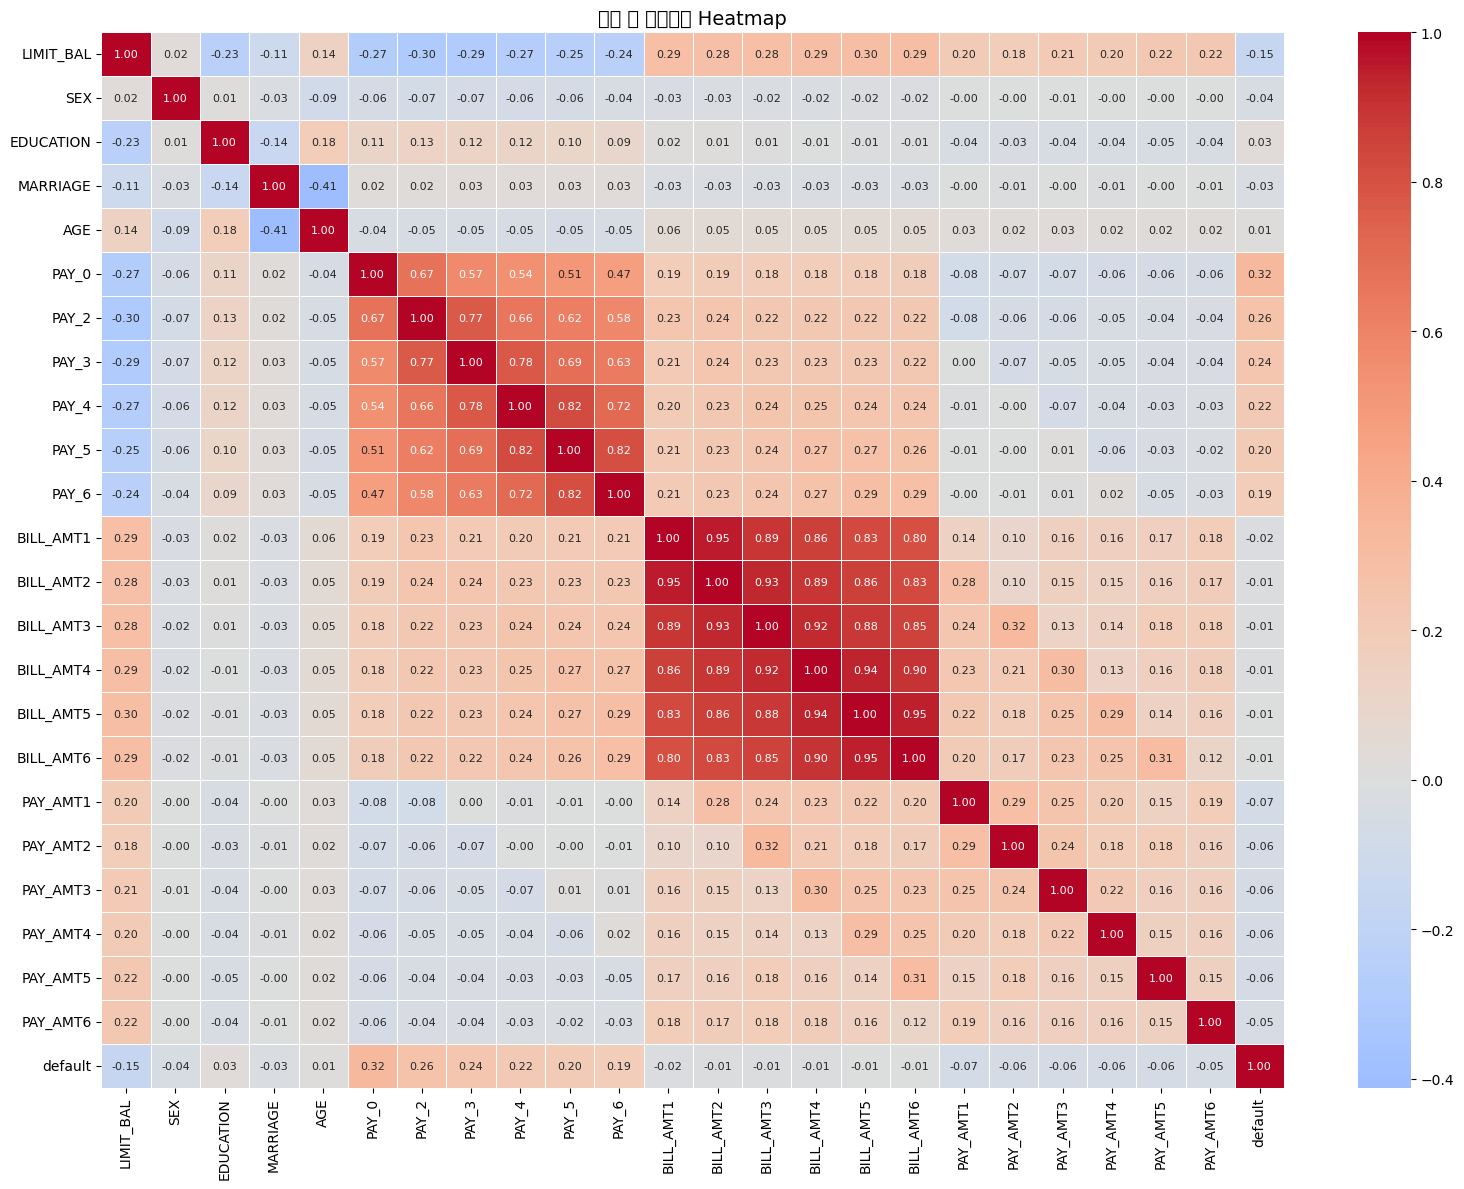

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.033842
MARRIAGE     0.027575
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372
Name: default, dtype: float64


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 피처 + target 상관관계
corr = card_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('피처 간 상관관계 Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# target과의 상관관계 순위
print("=== default 와의 상관관계 (절대값 내림차순) ===")
print(corr['default'].drop('default').abs().sort_values(ascending=False))

상관관계 분석 결과

default 와의 상관관계 (예측 기여도)

- PAY_0 0.32 → 가장 높음, 핵심 예측 피처
- PAY_2 0.26, PAY_3 0.24, PAY_4 0.22, PAY_5 0.20, PAY_6 0.19 → 연체 상태 피처군 전반적으로 유효
- LIMIT_BAL -0.15 → 신용한도 높을수록 채무불이행 낮음
- BILL_AMT1~6 : -0.02 ~ -0.01 → 상관관계 거의 없음
- SEX, EDUCATION, MARRIAGE, AGE : 0.01 ~ 0.04 → 예측 기여도 매우 낮음

피처 간 다중공선성 주의

- BILL_AMT1 ~ BILL_AMT6 간 상관계수 0.80 ~ 0.95 → 매우 높음, 다중공선성 존재
- PAY_0 ~ PAY_6 간 상관계수 0.47 ~ 0.82 → 높음
- MARRIAGE ↔ AGE : -0.41 → 음의 상관관계 (나이 많을수록 기혼 비율 높음)

모델링 시사점

- PAY_0 ~ PAY_6 연체 상태 피처군이 예측에 가장 중요
- BILL_AMT 피처군은 다중공선성이 높아 트리 기반 모델에서 중요도가 분산될 수 있음
- SEX, AGE, EDUCATION, MARRIAGE 는 예측 기여도 낮으나 제거 여부는 모델 성능 비교 후 결정

데이터 전처리

In [70]:
# EDUCATION : 0, 5, 6 → 4 (기타) 로 통합
X_features['EDUCATION'] = X_features['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE : 0 → 3 (기타) 로 통합
X_features['MARRIAGE'] = X_features['MARRIAGE'].replace({0: 3})

# 전처리 결과 확인
print("=== EDUCATION 값 분포 ===")
print(X_features['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 값 분포 ===")
print(X_features['MARRIAGE'].value_counts().sort_index())

=== EDUCATION 값 분포 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


# 추가 전처리 검토 결과**

- 범주형 피처 인코딩 : SEX, EDUCATION, MARRIAGE 는 이미 정수 인코딩 완료 → 추가 인코딩 불필요
- 수치형 피처 스케일링 : Random Forest, XGBoost 는 트리 기반으로 스케일 영향 없음 → Logistic Regression 모델 학습 시에만 StandardScaler 적용
- 불필요 컬럼 제거 : 상관계수 낮은 피처(SEX, AGE 등) 는 현 단계에서 유지, 6단계 피처 중요도 확인 후 제거 여부 결정

→ 추가 전처리 없이 Train/Test Split 으로 진행

# Train / Test Split

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target   # 클래스 비율 유지
)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train 클래스 비율\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  클래스 비율\n{y_test.value_counts(normalize=True).round(3)}")

X_train : (24000, 23), X_test : (6000, 23)
y_train 클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64

y_test  클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64


# 모델 학습

베이스라인 : Random Forest Classifier (class_weight 미적용) 비교 1 : Random Forest Classifier (class_weight='balanced') 비교 2 : Random Forest Classifier + SMOTE 오버샘플링

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 베이스라인 RFC (class_weight 미적용)
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print("=== 베이스라인 RFC ===")
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")

=== 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7572


# 베이스라인 RFC 결과 분석**


| 구분 | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| 정상(0) | 0.84 | 0.94 | 0.89 | 4673 |
| 채무불이행(1) | 0.64 | 0.36 | 0.46 | 1327 |

- Accuracy: 0.81
- ROC-AUC: 0.7572

문제점

- 채무불이행(1) Recall = 0.36 → 실제 채무불이행 고객 중 64%를 정상으로 잘못 분류
- 클래스 불균형(4:1)의 영향으로 모델이 다수 클래스(정상)에 편향
- Accuracy 0.81은 높아 보이나 신뢰 불가 → 불균형 데이터에서 무의미한 지표

→ class_weight='balanced' 적용으로 Recall 개선 시도

In [72]:
# 비교 1 : RFC + class_weight='balanced'
rfc_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== RFC (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}")

=== RFC (class_weight='balanced') ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7583


# RFC class_weight='balanced' 결과 분석

### RFC class_weight='balanced' 결과 분석

| 지표 | 베이스라인 | class_weight='balanced' | 변화 |
|---|---:|---:|---|
| 채무불이행 Recall | 0.36 | 0.34 | ↓ |
| 채무불이행 F1 | 0.46 | 0.45 | ↓ |
| ROC-AUC | 0.7572 | 0.7583 | ↑ (미미) |

**해석**
- `class_weight='balanced'` 적용 후 채무불이행 Recall/F1이 소폭 하락
- ROC-AUC는 소폭 상승했지만 실질 개선은 제한적
- 목표(채무불이행 미탐지 감소) 기준에서는 효과 부족

-> 다음 단계: `SMOTE + RFC`로 Recall 개선 시도



In [73]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 (train 데이터에만)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== SMOTE 적용 후 train 클래스 분포 ===")
print(y_train_smote.value_counts())
print(f"\n정상(0)     : {y_train_smote.value_counts()[0]:,}명")
print(f"채무불이행(1): {y_train_smote.value_counts()[1]:,}명")

=== SMOTE 적용 후 train 클래스 분포 ===
default
0    18691
1    18691
Name: count, dtype: int64

정상(0)     : 18,691명
채무불이행(1): 18,691명


In [74]:
# 비교 2 : RFC + SMOTE
rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]

print("\n=== RFC + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")


=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7443


# 3개 모델 비교 결과 (채무불이행(1) 기준)

| 모델 | Precision | Recall | F1-Score | ROC-AUC | Accuracy |
|---|---:|---:|---:|---:|---:|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 | 0.81 |
| RFC (`class_weight='balanced'`) | 0.64 | 0.34 | 0.45 | 0.7583 | 0.81 |
| RFC + SMOTE | 0.51 | 0.48 | 0.49 | 0.7443 | 0.78 |

- SMOTE 적용 시 Recall 0.36 → 0.48 로 가장 큰 개선 (+0.12)
- 단, Precision 0.64 → 0.51 로 하락 → 정상 고객을 채무불이행으로 잘못 분류하는 비율 증가
- ROC-AUC 는 세 모델 모두 0.74 ~ 0.76 수준으로 유사
- 채무불이행 탐지(Recall) 관점에서는 SMOTE 모델이 가장 우수

→ **채무불이행 탐지가 목적인 비즈니스 관점에서 RFC + SMOTE 를 최종 모델로 선택**